# Predicting Credit Card Approvals with Logistic Regression

This notebook builds an automatic credit card approval predictor with:

- missing value handling
- categorical feature processing
- feature scaling
- class imbalance handling
- automatic hyperparameter optimization with `GridSearchCV`


## 1. Imports and configuration

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)


## 2. Load dataset

The notebook tries `data/credit_approval.csv` first. If it is not found, it loads the UCI dataset URL.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
LOCAL_DATA_PATH = Path("data/credit_approval.csv")

column_names = [f"A{i}" for i in range(1, 16)] + ["target"]

if LOCAL_DATA_PATH.exists():
    raw_df = pd.read_csv(LOCAL_DATA_PATH)
    if "target" not in raw_df.columns:
        raw_df.columns = column_names
    print(f"Loaded local dataset: {LOCAL_DATA_PATH}")
else:
    raw_df = pd.read_csv(DATA_URL, header=None, names=column_names)
    print(f"Loaded dataset from URL: {DATA_URL}")

print("Shape:", raw_df.shape)
raw_df.head()


Loaded dataset from URL: https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data
Shape: (690, 16)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,target
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


## 3. Clean data and target labels

In [3]:
df = raw_df.copy()

# UCI encodes missing values with '?'.
df = df.replace("?", np.nan)

# Normalize possible label formats to 0/1.
target_map = {
    "+": 1,
    "-": 0,
    "Y": 1,
    "N": 0,
    1: 1,
    0: 0,
    "1": 1,
    "0": 0,
}
df["target"] = df["target"].map(target_map)
df = df.dropna(subset=["target"]).copy()
df["target"] = df["target"].astype(int)

X = df.drop(columns=["target"]).copy()
y = df["target"].copy()

print("Dataset shape after target cleaning:", df.shape)
print("\nTarget distribution:")
print(y.value_counts(dropna=False))
print("\nTarget ratio:")
print(y.value_counts(normalize=True).round(3))


Dataset shape after target cleaning: (690, 16)

Target distribution:
target
0    383
1    307
Name: count, dtype: int64

Target ratio:
target
0    0.555
1    0.445
Name: proportion, dtype: float64


## 4. Detect numeric/categorical columns and split data

In [4]:
X_typed = X.copy()

# Convert columns to numeric when at least 80% of non-missing values are numeric-like.
for col in X_typed.columns:
    parsed = pd.to_numeric(X_typed[col], errors="coerce")
    non_missing = X_typed[col].notna().sum()
    parsed_non_missing = parsed.notna().sum()
    if non_missing > 0 and (parsed_non_missing / non_missing) >= 0.8:
        X_typed[col] = parsed

numeric_features = X_typed.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_typed.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

print("\nMissing values by column:")
display(X_typed.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

X_train, X_test, y_train, y_test = train_test_split(
    X_typed,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("\nTrain shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train class ratio:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test class ratio:", y_test.value_counts(normalize=True).round(3).to_dict())


Numeric features: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Categorical features: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']

Missing values by column:


,missing_count
A14,13
A2,12
A1,12
A6,9
A7,9
A4,6
A5,6
A3,0
A8,0
A10,0



Train shape: (552, 15) | Test shape: (138, 15)
Train class ratio: {0: 0.554, 1: 0.446}
Test class ratio: {0: 0.558, 1: 0.442}


## 5. Build preprocessing + Logistic Regression pipeline and optimize with GridSearchCV

In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]
)

# Include class_weight in search to address class imbalance.
param_grid = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__class_weight": [None, "balanced"],
    },
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__class_weight": [None, "balanced"],
    },
]

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

cv_results = pd.DataFrame(grid_search.cv_results_).sort_values(
    by="mean_test_roc_auc", ascending=False
)
cv_results[
    [
        "rank_test_roc_auc",
        "mean_test_roc_auc",
        "mean_test_balanced_accuracy",
        "mean_test_f1",
        "param_model__solver",
        "param_model__penalty",
        "param_model__C",
        "param_model__class_weight",
    ]
].head(10)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.9182


,rank_test_roc_auc,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_f1,param_model__solver,param_model__penalty,param_model__C,param_model__class_weight
8,1,0.918241,0.848431,0.832281,liblinear,l1,1.0,None
10,2,0.917517,0.859798,0.845799,liblinear,l1,1.0,balanced
24,3,0.916636,0.839895,0.822186,lbfgs,l2,1.0,None
9,4,0.916569,0.839895,0.822186,liblinear,l2,1.0,None
25,5,0.915579,0.851650,0.836494,lbfgs,l2,1.0,balanced
11,6,0.915378,0.851650,0.836494,liblinear,l2,1.0,balanced
5,7,0.914094,0.850534,0.833564,liblinear,l2,0.1,None
7,8,0.913632,0.858520,0.844800,liblinear,l2,0.1,balanced
13,9,0.913407,0.832943,0.813609,liblinear,l2,10.0,None
26,10,0.913407,0.832943,0.813609,lbfgs,l2,10.0,None


## 6. Evaluate on the test set

Test metrics:


,value
accuracy,0.8623
balanced_accuracy,0.8630
precision,0.8281
recall,0.8689
f1,0.8480
roc_auc,0.9636
average_precision,0.9464


Classification report:
              precision    recall  f1-score   support

           0     0.8919    0.8571    0.8742        77
           1     0.8281    0.8689    0.8480        61

    accuracy                         0.8623       138
   macro avg     0.8600    0.8630    0.8611       138
weighted avg     0.8637    0.8623    0.8626       138



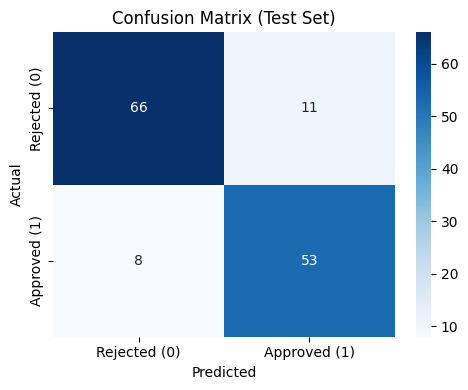

In [6]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "average_precision": average_precision_score(y_test, y_proba),
}

print("Test metrics:")
display(pd.Series(metrics).round(4).to_frame("value"))

print("Classification report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected (0)", "Approved (1)"],
    yticklabels=["Rejected (0)", "Approved (1)"],
)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 7. Inspect top weighted features

In [7]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
coefficients = best_model.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
        "abs_coefficient": np.abs(coefficients),
    }
).sort_values("abs_coefficient", ascending=False)

print("Top features by absolute coefficient:")
coef_df.head(20)


Top features by absolute coefficient:


,feature,coefficient,abs_coefficient
5,num__A15,1.769166,1.769166
19,cat__A6_ff,-1.756233,1.756233
38,cat__A9_t,1.624750,1.624750
44,cat__A13_p,1.523979,1.523979
27,cat__A6_x,1.451167,1.451167
37,cat__A9_f,-1.290336,1.290336
16,cat__A6_cc,0.798302,0.798302
10,cat__A4_y,-0.655309,0.655309
20,cat__A6_i,-0.620531,0.620531
39,cat__A10_f,-0.567092,0.567092


## 8. Save the best model pipeline

In [8]:
model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "best_logreg_credit_approval.joblib"
joblib.dump(best_model, model_path)

print(f"Saved model pipeline to: {model_path.resolve()}")


Saved model pipeline to: C:\Projects\Predict_credit_card_approvals\models\best_logreg_credit_approval.joblib


## 9. Next step ideas

- Replicate the same structure with LendingClub data.
- Tune decision threshold for business costs (false approvals vs false rejections).
- Add calibration and model monitoring metrics before deployment.
